In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
MODEL_DIR = Path("../models")

final_model = joblib.load(
    MODEL_DIR / "reference_based_random_forest.joblib"
)

delta_columns = joblib.load(
    MODEL_DIR / "delta_feature_names.joblib"
)

In [3]:
df = pd.read_csv(
    "../data/processed/audio_features.csv"
)

In [4]:
feature_columns = [
    col for col in df.columns
    if col.startswith((
        "rms_",
        "zcr_",
        "centroid_",
        "bandwidth_",
        "rolloff_",
        "mfcc_"
    ))
]

reference_features = (
    df[df["process"] == "reference"]
    .set_index("item")[feature_columns]
)

delta_df = df.copy()

for feature in feature_columns:

    delta_df[f"delta_{feature}"] = (
        delta_df[feature]
        - delta_df["item"].map(
            reference_features[feature]
        )
    )

In [5]:
processed_df = delta_df[
    delta_df["process"] != "reference"
].copy()

X_processed = processed_df[delta_columns]

print(X_processed.shape)

(210, 36)


In [6]:
explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer.shap_values(
    X_processed
)

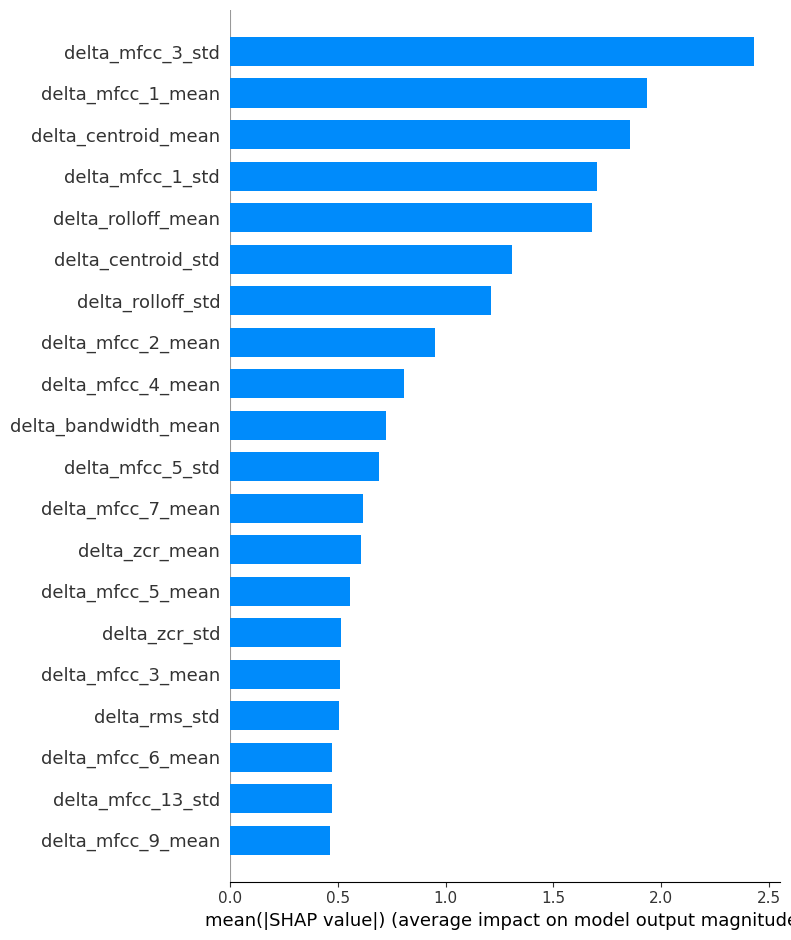

In [7]:
shap.summary_plot(
    shap_values,
    X_processed,
    plot_type="bar"
)

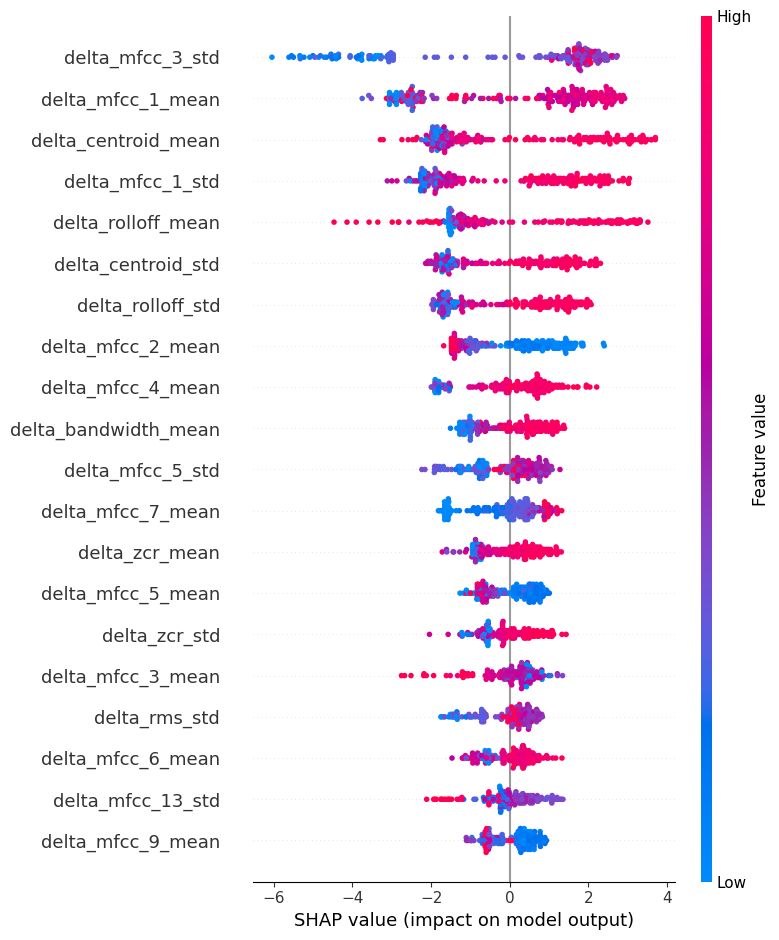

In [8]:
shap.summary_plot(
    shap_values,
    X_processed
)

In [9]:
shap_explanation = shap.Explainer(
    final_model,
    X_processed
)(X_processed)

 96%|=================== | 202/210 [00:11<00:00]       

In [10]:
low_idx = processed_df["score_mean"].reset_index(drop=True).idxmin()

processed_df.reset_index(drop=True).iloc[low_idx][
    ["item", "process", "score_mean"]
]

item          SH_13_glockenspiel
process                  SH70_MS
score_mean             10.576923
Name: 135, dtype: object

In [11]:
x_low = X_processed.reset_index(drop=True).iloc[[low_idx]]

prediction = final_model.predict(x_low)[0]

print("True score:", processed_df.reset_index(drop=True).iloc[low_idx]["score_mean"])
print("Predicted score:", prediction)

True score: 10.576923076923077
Predicted score: 20.695456027306072


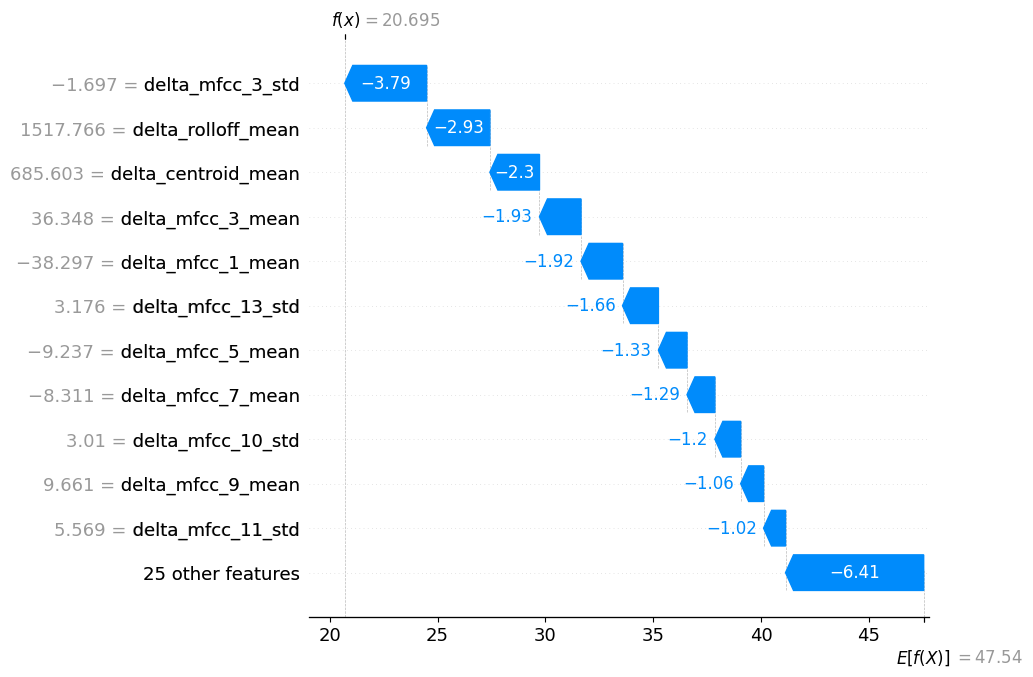

In [12]:
shap.plots.waterfall(
    shap_explanation[low_idx],
    max_display=12
)

item          LP_CreatureFromTheBlackjackTable
process                                  LP150
score_mean                           97.807692
Name: 97, dtype: object
Prediction: 80.00471542207778


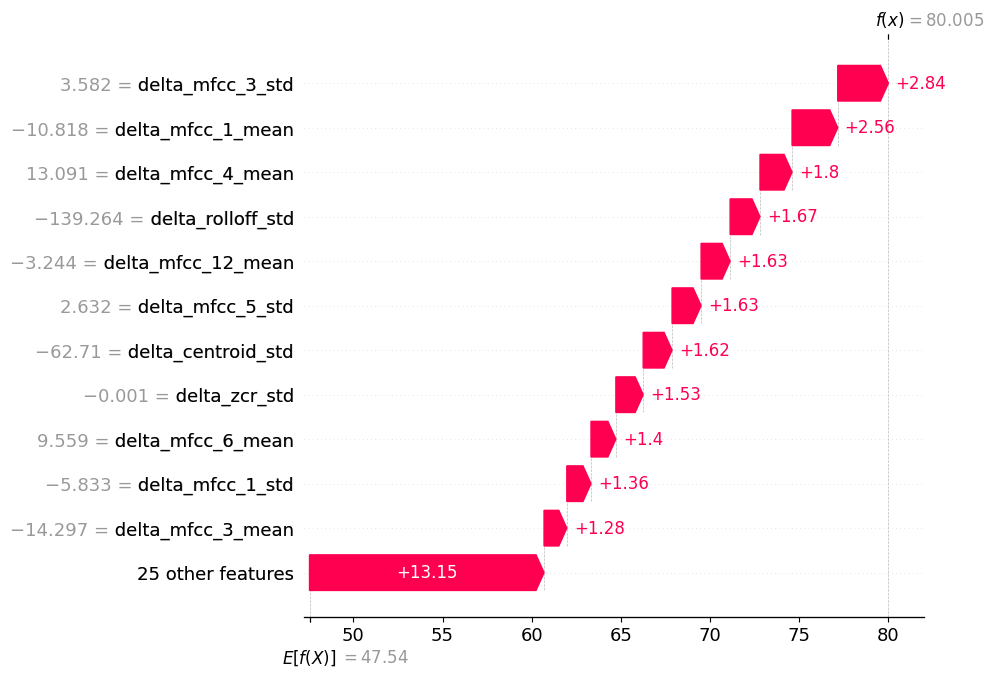

In [13]:
high_idx = (
    processed_df["score_mean"]
    .reset_index(drop=True)
    .idxmax()
)

x_high = X_processed.reset_index(drop=True).iloc[[high_idx]]

print(
    processed_df
    .reset_index(drop=True)
    .iloc[high_idx][
        ["item", "process", "score_mean"]
    ]
)

print(
    "Prediction:",
    final_model.predict(x_high)[0]
)

shap.plots.waterfall(
    shap_explanation[high_idx],
    max_display=12
)

In [15]:
final_model = joblib.load(
    "../models/final_reference_based_rf.joblib"
)

enhanced_features = joblib.load(
    "../models/final_feature_names.joblib"
)

In [21]:
import pandas as pd
import numpy as np
df = pd.read_csv(
    "../data/processed/audio_features.csv"
)
feature_columns = [
    col for col in df.columns
    if col.startswith((
        "rms_",
        "zcr_",
        "centroid_",
        "bandwidth_",
        "rolloff_",
        "mfcc_"
    ))
]
reference_features = (
    df[df["process"] == "reference"]
    .set_index("item")[feature_columns]
)
delta_df = df.copy()

delta_columns = []

for feature in feature_columns:

    delta_col = f"delta_{feature}"

    delta_df[delta_col] = (
        delta_df[feature]
        - delta_df["item"].map(
            reference_features[feature]
        )
    )

    delta_columns.append(delta_col)
processed_df = delta_df[
    delta_df["process"] != "reference"
].copy()
abs_delta_columns = []

for col in delta_columns:

    new_col = f"abs_{col}"

    processed_df[new_col] = np.abs(
        processed_df[col]
    )

    abs_delta_columns.append(new_col)
    enhanced_features = (
    delta_columns
    + abs_delta_columns
)

X_enhanced = processed_df[
    enhanced_features
]

print(X_enhanced.shape)
print(
    enhanced_features
    == list(final_model.feature_names_in_)
)
explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer.shap_values(
    X_enhanced
)

(210, 72)
True


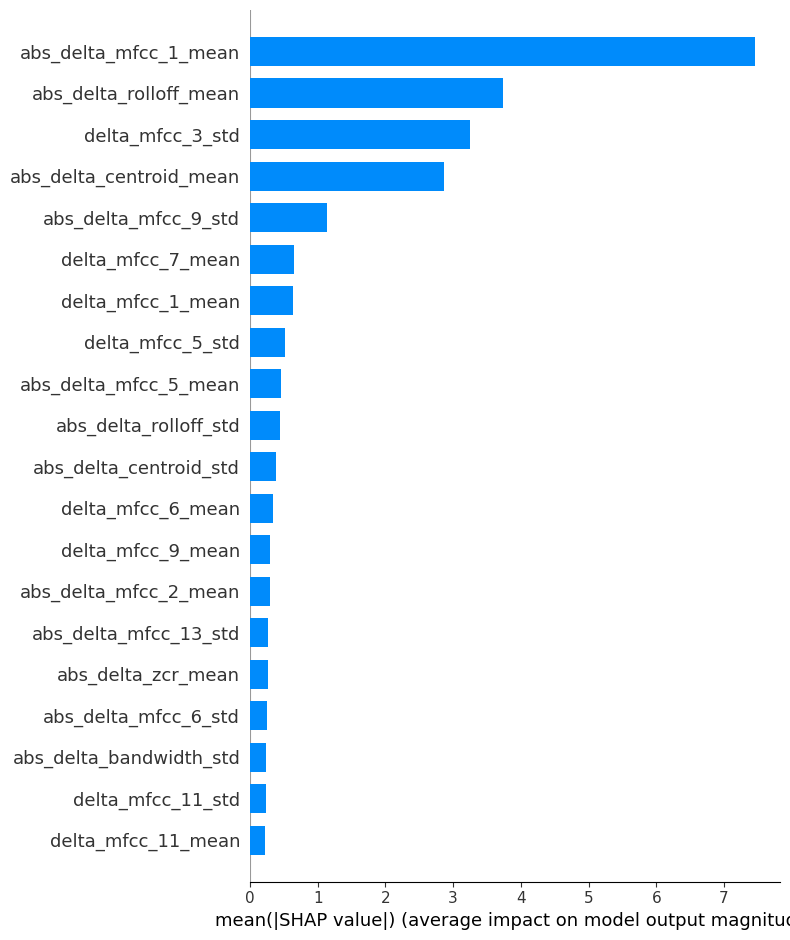

In [22]:
shap.summary_plot(
    shap_values,
    X_enhanced,
    plot_type="bar"
)

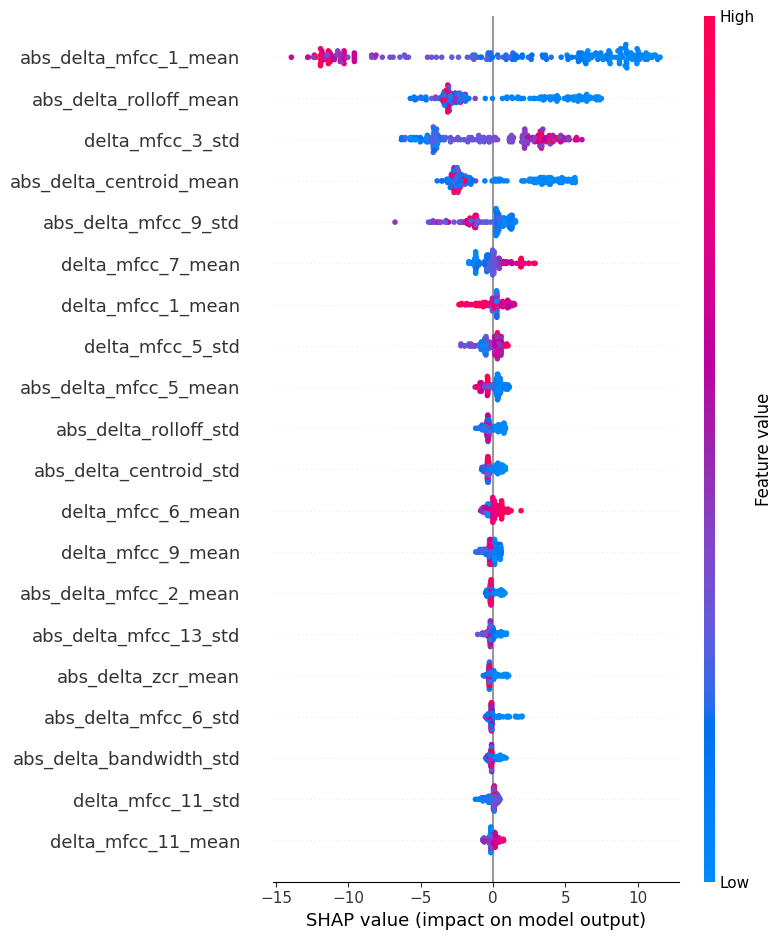

In [23]:
shap.summary_plot(
    shap_values,
    X_enhanced,
    max_display=20
)

In [25]:
processed_reset = processed_df.reset_index(drop=True)

X_final = X_enhanced.reset_index(drop=True)

print(processed_reset.shape)
print(X_final.shape)

X_final = X_enhanced.reset_index(drop=True)

shap_explainer = shap.Explainer(
    final_model,
    X_final
)

shap_exp = shap_explainer(X_final)

(210, 116)
(210, 72)


In [26]:
shap_explainer = shap.Explainer(
    final_model,
    X_final
)

shap_exp = shap_explainer(X_final)

item          SH_13_glockenspiel
process                  SH70_MS
score_mean             10.576923
Name: 135, dtype: object
Predicted score: 17.400441321654366


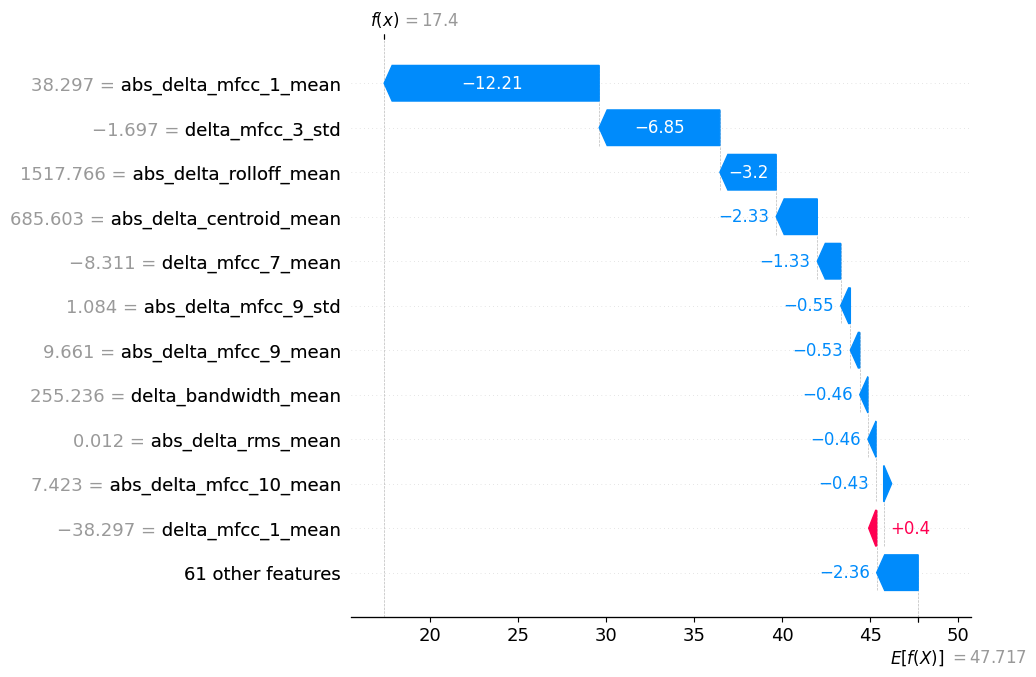

In [27]:
low_idx = processed_reset["score_mean"].idxmin()

print(
    processed_reset.loc[
        low_idx,
        ["item", "process", "score_mean"]
    ]
)

print(
    "Predicted score:",
    final_model.predict(
        X_final.iloc[[low_idx]]
    )[0]
)

shap.plots.waterfall(
    shap_exp[low_idx],
    max_display=12
)

item          LP_CreatureFromTheBlackjackTable
process                                  LP150
score_mean                           97.807692
Name: 97, dtype: object
Predicted score: 77.65231331000739


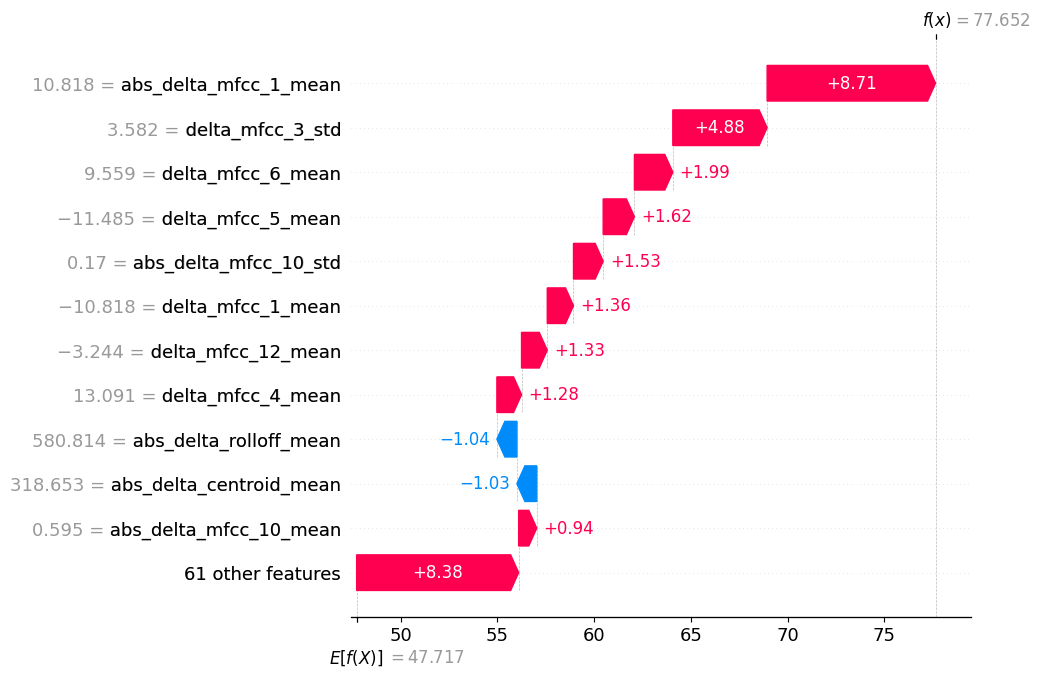

In [28]:
high_idx = processed_reset["score_mean"].idxmax()

print(
    processed_reset.loc[
        high_idx,
        ["item", "process", "score_mean"]
    ]
)

print(
    "Predicted score:",
    final_model.predict(
        X_final.iloc[[high_idx]]
    )[0]
)

shap.plots.waterfall(
    shap_exp[high_idx],
    max_display=12
)
